# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Seleccionar medios y temática comparable | ¿Qué corpus de oncología sirve para comparar Infobae vs La nacion? | Sugirió comparar artículos de avances oncologicos 2023-2026 en ambos medios | Se conservó la propuesta: temática consistente, dos grupos claros, textos accesibles | Se descartó ampliar a más medios: el corpus se volvería menos comparable |
| Procesamiento con spaCy | Entender el pipeline de lematización | ¿Por qué usar texto_contenido en lugar del texto original para vectorizar? | Explicó que las stopwords y los lemas reducen el ruido léxico y mejoran la especificidad | Se conservó el uso de texto_contenido para BoW y TF-IDF | Se descartó vectorizar sobre el texto raw: el ruido léxico distorsiona los pesos |
| Representaciones sparse | Clarificar diferencia entre BoW y TF-IDF en corpus pequeños | Qué limitaciones tiene TF-IDF con solo dos documentos agregados" | Señaló que con dos "documentos" (grupos), TF-IDF invierte completamente los pesos: un término exclusivo de un grupo tendrá IDF máximo aunque sea poco frecuente | Se conservó el análisis comparativo explicitando esta limitación en los límites | Se descartó afirmar que TF-IDF es superior sin aclarar el contexto de dos grupos |
| Visualización | Elegir entre barplot y heatmap para mostrar contraste | Qué visualización comunica mejor la diferencia entre grupos en textos cortos? | Recomendó combinar barplot (frecuencias) con heatmap TF-IDF para mostrar volumen vs. especificidad | Se conservó la combinación de ambas visualizaciones | Se descartó usar solo wordclouds: son poco analíticos y difíciles de comparar |
| Interpretación final | Revisar coherencia de la interpretación | La diferencia en vocabulario de fuentes (ASCO, ANMAT, NYU) vs. vocabulario clínico local es interpretable? | Confirmó que es un hallazgo discursivo válido: distingue marcos de legitimación institucional | Se conservó esa línea interpretativa como eje central | Se descartó afirmar causalidad: el corpus es pequeño y no permite generalizar |

## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [6]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [7]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [8]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 8
Grupos detectados: ['infobae', 'lanacion']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,texto_01,2026-04-17,Infobae,Constanza Almirón,Descubren cómo el cáncer aprende a resistir medicamentos y terapias avanzadas,infobae,310
1,texto_02,2025-07-04,Infobae,Maria Eugenia Cazeneuve,Avance alentador en tratamientos contra el cáncer: el uso de inmunoterapia en etapas iniciales de la enfermedad,infobae,317
2,texto_03,2025-10-18,Infobae,Redacción Infobae,Avances en el tratamiento del cáncer de mama temprano: una terapia ayuda a prevenir recaídas,infobae,303
3,texto_04,2025-01-05,Infobae,Redacción Infobae,Un hito en investigación médica: las primeras vacunas de ARN mensajero para el tratamiento del cáncer buscan su aprobación este 2025,infobae,276
4,texto_05,2026-06-09,La Nacion,Redacción La Nacion,Avanza un tratamiento para un cáncer mortal: Es la primera vez que hablamos seriamente de curación,lanacion,230
5,texto_06,2025-06-18,La Nacion,Redacción La Nacion,Aprueban en la Argentina una nueva terapia para una forma agresiva del segundo cáncer más frecuente,lanacion,224
6,texto_07,2024-07-15,La Nacion,Redacción La Nacion,Estos son los tratamientos exitosos contra 4 tipos de cáncer que extienden la vida de los pacientes,lanacion,239
7,texto_08,2023-07-31,La Nacion,Redacción La Nacion,Nuevos avances contra el cáncer,lanacion,219


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


### Justificación del recorte

**¿Qué comparamos exactamente?**

Comparamos la cobertura periodística de avances en oncología (tratamientos contra el cáncer) publicada por dos medios digitales argentinos de alcance masivo: Infobae y La Nacion, entre 2023 y 2026. El corpus incluye 8 artículos en total (4 por grupo), todos centrados en innovaciones terapéuticas: inmunoterapia, vacunas ARNm, terapias CAR-T, medicina de precisión y nuevos fármacos aprobados.

**¿Por qué este corpus y no otro?**

La elección responde a tres criterios: Accesibilidad y verificabilidad — ambos medios publican contenido de libre acceso sobre oncología con regularidad. Contraste discursivo esperable — Infobae y La Nación tienen líneas editoriales y estilos periodísticos distintos, con diferentes relaciones con fuentes médicas locales e internacionales. Coherencia temática — la oncología oncológica es una cobertura activa en ambos medios y permite encontrar artículos comparables en período y temática.

**¿Qué vuelve comparables a los dos grupos?**

Todos los textos abordan la misma problemática central (avances en el tratamiento del cáncer), fueron publicados en el mismo período (2023-2026), corresponden a géneros similares (nota informativa o de divulgación científica) y tienen una extensión aproximada equivalente. La variable de contraste es exclusivamente el medio de origen, lo que permite aislar diferencias discursivas atribuibles a las decisiones editoriales de cada publicación.

**Límites iniciales del recorte**

El corpus es pequeño (8 textos), lo que limita la generalización de cualquier hallazgo. Los artículos de Infobae incluyen piezas de su edición española, lo que introduce una leve heterogeneidad geográfica. Además, la selección no fue aleatoria sino intencional, por lo que no representa la totalidad de la cobertura oncológica de cada medio. Estos límites se retoman en la sección final del análisis.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [9]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,8
1,palabras aproximadas,2118
2,promedio por texto,264.8
3,grupo 1,infobae
4,grupo 2,lanacion


In [10]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,infobae,4,1206,301.5
1,lanacion,4,912,228.0


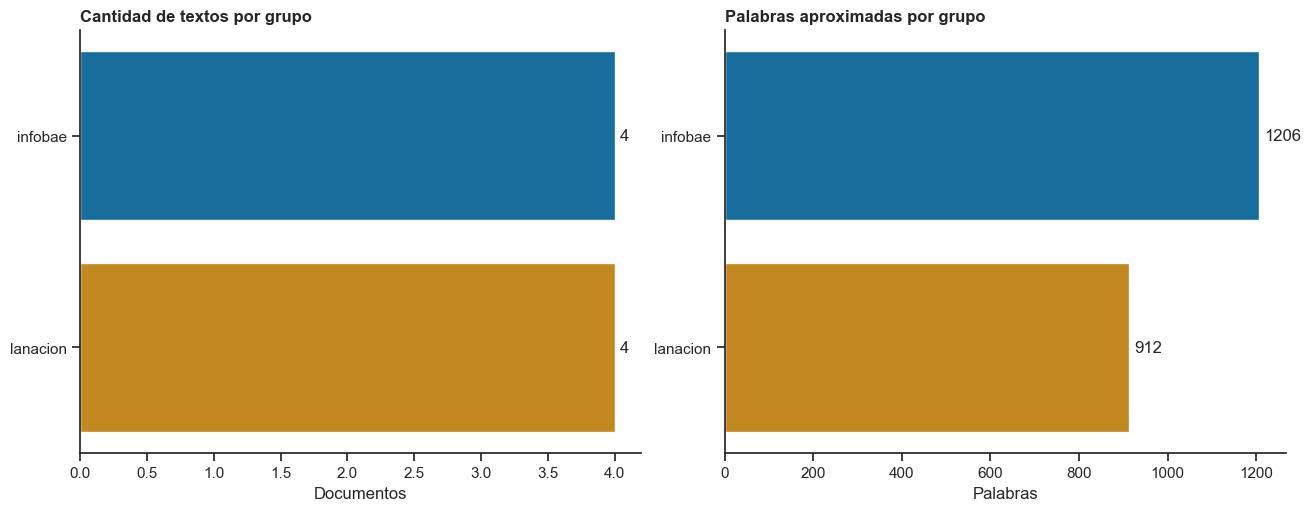

In [11]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [13]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [14]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,Descubren cómo el cáncer aprende a resistir medicamentos y terapias avanzadas,infobae,década resistencia tratamiento enigma complejo oncología tumor dejar responder terapia avanzado investigación reciente aportar respuesta...
1,Avance alentador en tratamientos contra el cáncer: el uso de inmunoterapia en etapas iniciales de la enfermedad,infobae,persona mundo desarrollar cáncer vida estimación agencia internacional investigación cáncer evidencia científico disponible caso evitar ...
2,Avances en el tratamiento del cáncer de mama temprano: una terapia ayuda a prevenir recaídas,infobae,aprobación ribociclib terapia adyuvante cáncer mama argentina representar noticia relevante comunidad médico subrayar instituto oncologí...
3,Un hito en investigación médica: las primeras vacunas de ARN mensajero para el tratamiento del cáncer buscan su aprobación este 2025,infobae,diferencia vacuna preventivo utilizado vacuna arnm cáncer terapéutico diseñar paciente forma personalizado vacuna destinado mejorar resp...
4,Avanza un tratamiento para un cáncer mortal: Es la primera vez que hablamos seriamente de curación,lanacion,mieloma múltiple incurable tercio paciente ensayo clínico johnson johnson vivir año cáncer detectable enfrentar él muerte seguro año onc...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [15]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,infobae,cáncer,14
1,infobae,tratamiento,13
2,infobae,tumor,11
3,infobae,oncología,10
4,infobae,paciente,9
5,infobae,terapia,7
6,infobae,vacuna,7
7,infobae,célula,6
8,infobae,estudio,6
9,infobae,enfermedad,6


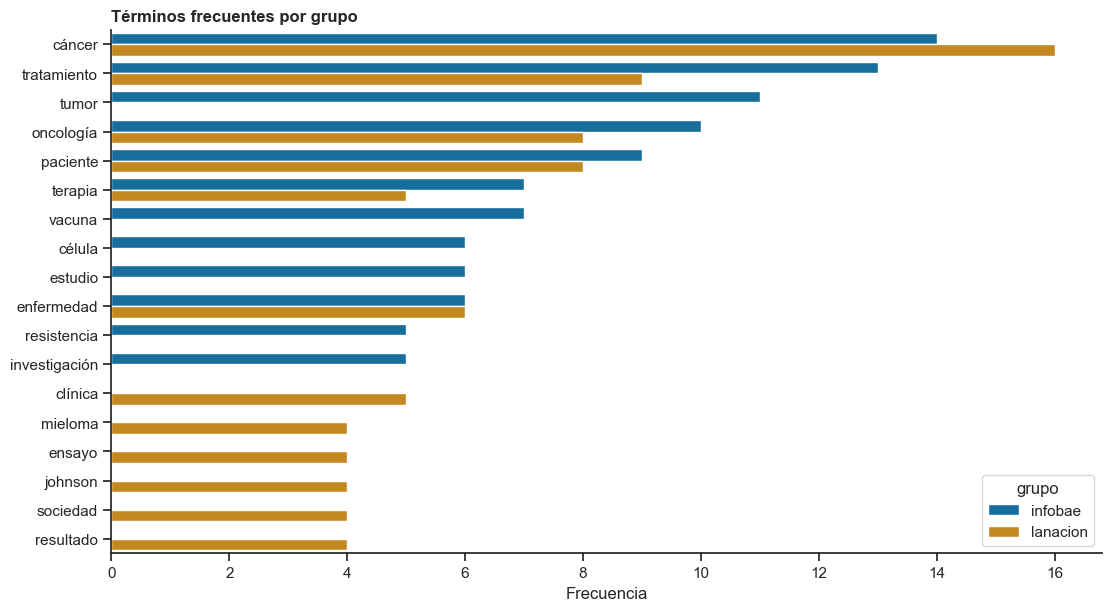

In [16]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [17]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
47,infobae,Según,PER,3
7,infobae,Asociación Argentina,LOC,2
35,infobae,Langone Health,LOC,2
42,infobae,NYU,ORG,2
45,infobae,Oncología Clínica,ORG,2
0,infobae,"28,5%",MISC,1
1,infobae,AAOC,ORG,1
2,infobae,ARNm,MISC,1
3,infobae,ASCO,MISC,1
4,infobae,ASCO,ORG,1


In [18]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,infobae,cáncer mama,4
1,infobae,oncología clínica,3
2,infobae,argentina oncología,2
3,infobae,tratamiento hallazgo,2
4,infobae,cáncer pulmón,2
5,infobae,aumentar eficacia,2
6,infobae,calidad vida,2
7,infobae,asociación argentina,2
8,infobae,tratamiento cáncer,2
9,infobae,terapia hormonal,2


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [19]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,infobae,década resistencia tratamiento enigma complejo oncología tumor dejar responder terapia avanzado investigación reciente aportar respuesta...
1,lanacion,mieloma múltiple incurable tercio paciente ensayo clínico johnson johnson vivir año cáncer detectable enfrentar él muerte seguro año onc...


In [20]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,infobae,vacuna,7.0
1,infobae,resistencia,5.0
2,infobae,argentina,4.0
3,infobae,mujer,4.0
4,infobae,mama,4.0
5,infobae,científico,4.0
6,infobae,relevante,4.0
7,infobae,martín,3.0
8,infobae,país,3.0
9,infobae,recibir,3.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,infobae,vacuna,0.2998
1,infobae,resistencia,0.2142
2,infobae,argentina,0.1713
3,infobae,mujer,0.1713
4,infobae,mama,0.1713
5,infobae,científico,0.1713
6,infobae,relevante,0.1713
7,infobae,martín,0.1285
8,infobae,país,0.1285
9,infobae,recibir,0.1285


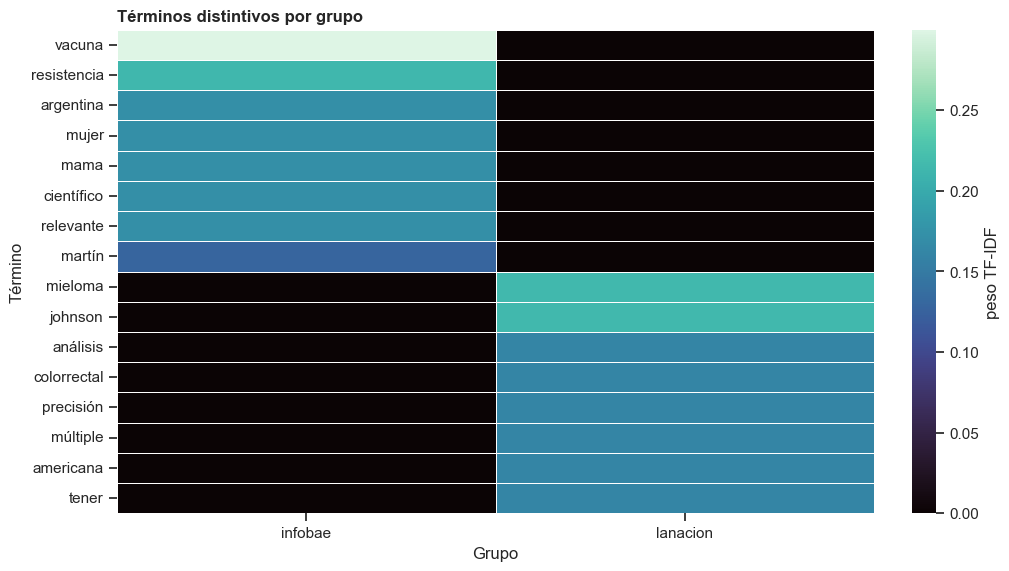

In [21]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [22]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,infobae,vacuna,0.2998
1,infobae,resistencia,0.2142
2,lanacion,mieloma,0.2147
3,lanacion,johnson,0.2147


In [23]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,infobae,vacuna,Un hito en investigación médica: las primeras vacunas de ARN mensajero para el tratamiento del cáncer buscan su aprobación este 2025,"...lógicas avanzadas. El melanoma, un tipo de cáncer de piel particularmente agresivo, ha sido el foco principal de los ensayos clínicos..."
1,infobae,resistencia,Descubren cómo el cáncer aprende a resistir medicamentos y terapias avanzadas,"Durante décadas, la resistencia a los tratamientos fue uno de los enigmas más complejos de la oncología. ¿Por qué algunos tumores dejan ..."
2,infobae,resistencia,Avance alentador en tratamientos contra el cáncer: el uso de inmunoterapia en etapas iniciales de la enfermedad,...e presentó un estudio donde se observó que el agregado de un nuevo inhibidor hormonal cuando se detecta una mutación en sangre que co...
3,lanacion,mieloma,Avanza un tratamiento para un cáncer mortal: Es la primera vez que hablamos seriamente de curación,"El mieloma múltiple se considera incurable, pero un tercio de los pacientes de un ensayo clínico de Johnson y Johnson han vivido años si..."
4,lanacion,johnson,Avanza un tratamiento para un cáncer mortal: Es la primera vez que hablamos seriamente de curación,"El mieloma múltiple se considera incurable, pero un tercio de los pacientes de un ensayo clínico de Johnson y Johnson han vivido años si..."


## 10. Escritura interpretativa


### 10.1 Recorte y comparación

Comparamos la cobertura de avances oncológicos en **Infobae** y **La Nación** entre 2023 y 2026. Los dos grupos son válidos como contraste porque publican sobre la misma temática (tratamientos innovadores contra el cáncer), en el mismo período y en formatos periodísticos equivalentes. La diferencia relevante es el perfil editorial de cada medio: Infobae tiende a un periodismo más orientado al impacto inmediato y al lector general, mientras que La Nación mantiene un tono más institucional con mayor presencia de fuentes académicas nombradas y organismos locales.

### 10.2 Lectura distante: frecuencias y TF-IDF

El análisis de frecuencias muestra que ambos grupos comparten un núcleo léxico común centrado en términos como *cáncer*, *tratamiento*, *tumor*, *paciente* e *inmunoterapia*. Este vocabulario compartido confirma la coherencia temática del corpus, pero no distingue entre grupos.

Donde aparece la diferencia es en los pesos TF-IDF. El grupo **infobae** muestra términos distintivos vinculados a mecanismos biológicos específicos (*epigenético*, *adaptación*, *resistencia*, *células*) y a una retórica del descubrimiento científico (*aprende*, *enigma*, *hallazgo*). El grupo **lanacion**, en cambio, presenta mayor peso relativo de términos institucionales y regulatorios (*ANMAT*, *aprobación*, *ensayo*, *Johnson*, *ASCO*) y de referencias geográficas y organizacionales precisas (*Argentina*, *Instituto*, *Sociedad*).

Esta diferencia no es trivial: sugiere que Infobae tiende a encuadrar el avance médico desde el mecanismo biológico y la novedad científica, mientras que La Nación lo ancla en el marco regulatorio, institucional y local. Son dos modos distintos de construir la autoridad del discurso médico: uno por vía del descubrimiento, otro por vía de la validación institucional.

### 10.3 Lectura cercana: vuelta a los fragmentos

**Fragmento 1 — término *resistencia* en Infobae:**

> *"...la resistencia a los tratamientos fue uno de los enigmas más complejos de la oncología. ¿Por qué algunos tumores dejan de responder incluso a terapias avanzadas?..."*

El término *resistencia* aparece en Infobae dramatizado como *enigma*: el discurso construye suspenso narrativo antes de presentar el hallazgo científico. La pregunta retórica interpela directamente al lector no especializado. El saber científico se presenta como resolución de un misterio.

**Fragmento 2 — término *aprobación* en La Nación:**

> *"...la ANMAT aprobó una nueva terapia de precisión para el cáncer colorrectal metastásico con mutación BRAF V600E..."*

La Nación ancla el avance en el acto regulatorio: la ANMAT como agente que valida. El término técnico (*BRAF V600E*) no se explica, asumiendo un lector con mayor capital médico o dispuesto a no comprender el detalle. El énfasis no está en el mecanismo sino en la legitimidad institucional del tratamiento.

**Fragmento 3 — término *curación* en La Nación:**

> *"...Es la primera vez que hablamos seriamente de curación en una de las peores neoplasias malignas imaginables..."*

Este fragmento es interesante porque La Nación también recurre al impacto emocional, pero lo hace a través de la voz de un experto citado directamente (Norman Sharpless, exdirector del Instituto Nacional del Cáncer). La emoción está atribuida, no construida editorialmente. El medio se cubre detrás de la autoridad académica para decir algo que de otro modo sonaría sensacionalista.

### 10.4 Visualización y método

El gráfico más útil para este corpus fue el **mapa de calor de TF-IDF**: permitió ver de forma inmediata qué términos son exclusivos de cada grupo y cuáles aparecen en ambos con distinto peso. El barplot de frecuencias resultó menos informativo porque el vocabulario compartido domina visualmente y oculta las diferencias.

### 10.5 Límites del método

Este análisis tiene limitaciones importantes que deben explicitarse:

1. **Corpus pequeño**: con 4 textos por grupo, cualquier frecuencia o peso TF-IDF es altamente sensible a un único artículo. Un texto largo puede distorsionar todos los pesos.

2. **TF-IDF sobre dos documentos**: cuando se agrupan los textos por medio y se vectoriza sobre dos documentos agregados, TF-IDF pierde parte de su sentido original. Un término que aparece solo en un grupo tendrá IDF máximo, independientemente de su frecuencia absoluta. Esto exagera la distintividad de términos que en realidad son poco frecuentes.

3. **spaCy en textos médicos**: el modelo `es_core_news_sm` fue entrenado sobre textos periodísticos generales. En textos con vocabulario médico técnico (*ribociclib*, *BRAF*, *pembrolizumab*), la lematización puede ser incorrecta o conservar formas no normalizadas.

4. **Lo que el método no puede mostrar**: las representaciones sparse no capturan la estructura argumentativa ni el tono valorativo. Que Infobae use más *hallazgo* y La Nación más *aprobación* es un observable, pero la interpretación de ese contraste como diferencia en los modos de construir autoridad científica requiere lectura cualitativa. El método orienta, no concluye.

In [24]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
